### Context engineering in Deep Agents
Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably. Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [17]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

GEMINI_MODEL = "google_genai:gemini-2.5-flash-lite"
GROQ_MODEL = "groq:qwen/qwen3.8-27b"

#### Context Engineering - Input Context - System Prompt

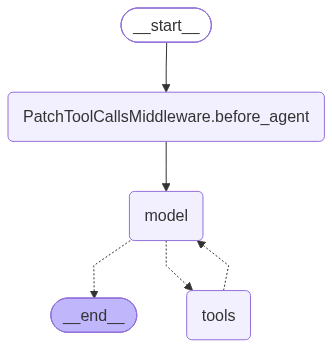

In [3]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model=GEMINI_MODEL,
    system_prompt=(
        "You are a research assistant specializing in scientific literature."
        "Always cite sources. Use subagents for parallel research on different topics."
    )
)
agent

In [4]:
result = agent.invoke({"messages": [{"role": "user", "content": "What is deepagent ?"}]})
result

{'messages': [HumanMessage(content='What is deepagent ?', additional_kwargs={}, response_metadata={}, id='bbab2ba8-7f0e-43ac-ba56-f29e50f16437'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'task', 'arguments': '{"subagent_type": "general-purpose", "description": "Research what \\"deepagent\\" is and provide a concise summary. Cite your sources."}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0679d-184e-7d81-9388-004fc125110e-0', tool_calls=[{'name': 'task', 'args': {'subagent_type': 'general-purpose', 'description': 'Research what "deepagent" is and provide a concise summary. Cite your sources.'}, 'id': 'df1ab7a7-5e60-49c1-952c-3a3ce43e8106', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2320, 'output_tokens': 38, 'total_tokens': 2358, 'input_token_details': {'cache_read': 1763}}),
  ToolMessage(content="I wasn't able

#### Context Engineering with `AGENTS.md`

Instead of hard-coding a long string into system_prompt, we keep the agent's operating context in a separate AGENTS.md file. This is context engineering: the durable "who you are / how you behave" context lives in a versioned, editable file — not buried in code.

In [5]:
from pathlib import Path
agents_md = Path("projects/AGENTS.md").read_text(encoding="utf-8")
agents_md

'# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, tools, and p

In [6]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()

#### Backends: where the agent's files/memory live
A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.Same agent code, different durability:,
| Backend                 | Lives in                          | Survives across                  | Use it when…                                                                 |
|-------------------------|-----------------------------------|----------------------------------|------------------------------------------------------------------------------|
| StateBackend (default)  | LangGraph state (the `files` channel) | one thread (with a checkpointer) | Scratch/working files for a single run or conversation. Ephemeral by design. |
| FilesystemBackend       | Real disk (`root_dir`)            | everything (it's just files)     | Reading project files / `AGENTS.md` that already exist on disk.              |
| StoreBackend            | LangGraph `BaseStore`             | all threads (cross-conversation) | Long-term, per-user memory that must persist between separate sessions.      |

In [7]:
agent = create_deep_agent(
    model = GEMINI_MODEL,
    checkpointer=MemorySaver(),
    # no backend, no memory, no files
)

result = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": f"Here is our project guide: \n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable": {"thread_id": "default-demo-1"}}, # fresh thread -> memory loads
)

print(result["messages"][-1].content)

I am a Deep Agent, an AI designed for complex, multi-step tasks. I will follow the operating guidelines outlined in this `Agents.md` file. This includes:

1.  **Planning first**: I will use the `write_todos` tool to create and update a plan before starting any task with multiple steps.
2.  **Aggressive offloading**: I will use file system tools (`read_file`, `write_file`, `edit_file`) to store large amounts of information, keeping the conversation concise.
3.  **Wise delegation**: I will use the `task` tool to delegate tasks to subagents when appropriate, providing them with clear instructions.
4.  **Single source of truth**: I will consider `Agents.md` as the definitive guide for my architecture and conventions.
5.  **Concise final answers**: My final answers will synthesize information from my notes and files, cite sources where applicable, and be brief.

What is my first task?


In [8]:
# --- Default backend (no backend= passed) ---
# With no backend specified, files/memory live in the agent's in-state filesystem.
# Since there's no disk access, memory reads from state — so we seed AGENTS.md via
# files= on invoke. (Without seeding, memory would silently load nothing.)

agent = create_deep_agent(
    model=GEMINI_MODEL,
    memory=["/projects/AGENTS.md"],
    checkpointer=MemorySaver()
)

In [9]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# Agents.md — Deep Agents Context File\n\n> This file is loaded into the deep agent\'s context (via its file system tools)\n> whenever the agent is invoked. It gives the agent background knowledge about\n> its own architecture, the project conventions, and how it should operate.\n\n---\n\n## 1. What is a Deep Agent?\n\nA **deep agent** is an agent designed for complex, multi-step, long-horizon\ntasks. Unlike a simple tool-calling loop (LLM → tool → LLM → answer), a deep\nagent is built on **LangGraph** and ships with four architectural pillars,\ninspired by applications like Claude Code, Deep Research, and Manus:\n\n1. **Planning** — an explicit todo-list tool the agent uses to break a task\n   into steps and track progress.\n2. **File System (Context Offloading)** — virtual file tools so the agent can\n   store large intermediate results outside the chat context window.\n3. **Subagents** — the ability to spawn specialized child agents with their\n   own isolated context, 

In [ ]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What is in your memory ? who are you ?"}],
        "files": {"/projects/AGENTS.md": create_file_data(agents_md)} # seed the in-state file
    },
    config={"configurable": {"thread_id": "default-demo-1"}} # fresh thread -> memory loads
)
print(result["messages"][-1].content)

I am a large language model, trained by Google. I have access to a file system and can read, write, edit, and delete files. I can also list files in a directory and search for files using glob patterns and grep. Additionally, I can launch subagents to perform complex tasks.


In [11]:
# --- StoreBackend: persistent, cross-thread memory ---
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory (e.g. per-user preferences the agent should recall
# next week). Here InMemoryStore is used for the demo; swap in a persistent store
# (e.g. Postgres) for real persistence.

from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# seed durable memory into store once. Namespace + key identify the file
store.put(("memories",), "AGENTS.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model=GEMINI_MODEL,
    backend=StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["/projects/AGENTS.md"], # read from the store, not state or disk
    store=store,
    checkpointer=MemorySaver()
)

# NOTE: no files = seeding needed - the store already holds it, and it would persist even if we started a branc-new thread or rebuilt the agent
result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "what is in your memory ? who are you ?"}]},
    config={"configurable": {"thread_id": "store-demo-1"}}
)

print(result["messages"][-1].content)

I am a large language model, trained by Google. I do not have memory in the same way humans do. I don't store personal information about past conversations or users. Each conversation starts fresh.


In [12]:
result

{'messages': [HumanMessage(content='what is in your memory ? who are you ?', additional_kwargs={}, response_metadata={}, id='4c2cee71-3335-4003-a19f-d3382509833a'),
  AIMessage(content="I am a large language model, trained by Google. I do not have memory in the same way humans do. I don't store personal information about past conversations or users. Each conversation starts fresh.", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a067cd-a467-7ed0-92f8-6103980d4e84-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3482, 'output_tokens': 41, 'total_tokens': 3523, 'input_token_details': {'cache_read': 0}})]}

In [18]:
# --- FilesystemBackend: read files/memory straight from DISK ---
# WHY: the agent's files and memory map to real files on disk under root_dir.
# Nothing to seed — if AGENTS.md exists on disk, memory just loads it. Best for
# project context (AGENTS.md, docs, code) that already lives in your repo.

from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

# root_dir = the projects/ folder, so paths are resolved relative to it.
# AGENTS.md sits directly inside projects/, so the memory path is just "AGENTS.md".
# virtual_mode=True confines the agent to root_dir (blocks '..' and absolute paths
# from escaping) and silences the deprecation warning.

fs_agent = create_deep_agent(
    model=GROQ_MODEL,
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["AGENTS.md"], # -> projects/AGENTS.md
    checkpointer=MemorySaver()
)

# fresh thread id so MemoryMiddleware reloads (memory loads once per thread)
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "what is in your memory ? who are you ?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}}
)

print(result["messages"][-1].content)

I'm a **deep agent** built on LangGraph — an agent designed for complex, multi-step, long-horizon tasks. My memory (the `AGENTS.md` context file) tells me I'm equipped with four key capabilities:

1. **Planning** — a todo-list tool to break tasks into steps and track progress
2. **File system** — virtual file tools to offload large data outside the context window
3. **Subagents** — I can spawn specialized child agents with isolated contexts
4. **Detailed system prompt** — teaching me when and how to use the above

In this project specifically, I'm built with `create_deep_agent`, a configurable chat model (via `init_chat_model`), and custom tools like **Tavily web search** for research.

**How I operate:**
- Plan first for multi-step tasks
- Offload bulky research/drafts to files to stay lean
- Delegate deep-dive work to subagents
- Treat `AGENTS.md` as my source of truth

Is there something I can help you build or research? 🚀


In [19]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "what is LLM gateways ?"}]},
    config={"configurable": {"thread_id": "fs-demo-2"}}
)

print(result["messages"][-1].content)

An **LLM gateway** (or LLM API gateway) is a single intermediary layer that sits between your applications and multiple LLM providers (OpenAI, Anthropic, Google, Mistral, local models, etc.). Instead of calling each provider directly with their own SDK, API key, and quirks, you route all requests through one unified endpoint that handles the messy cross-provider concerns.

## Core problems it solves

| Problem | What the gateway does |
|---|---|
| **Many providers, many SDKs** | One unified API (often OpenAI-compatible) for all models |
| **Key/secret sprawl** | Centralized key management, virtual keys per service/team |
| **Cost & quota control** | Rate limiting, budgets, per-key/team usage caps |
| **Reliability** | Retries, failover, load balancing across providers/models |
| **Observability** | Centralized logging of prompts, completions, token usage, latency |
| **Caching & routing** | Prompt caching, model routing (e.g., "use cheap model for easy tasks, premium for hard ones") |


##### Skills
Skills are reusable agent capabilities that provide specialized workflows and domain knowledge. You can use Agent Skills to provide your deep agent with new capabilities and expertise. For ready-to-use skills that improve your agent’s performance on LangChain ecosystem tasks, see the LangChain Skills repository. Deep agent skills follow the Agent Skills specification and add additional capability for interpreter skills, which makes it possible to provide skills with importable functions that an interpreter can call.

In [20]:
from urllib.request import urlopen
from pathlib import Path
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from deepagents import create_deep_agent
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

skills_content = Path("skills/langgraph/SKILL.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/langgraph/SKILL.md": create_file_data(skills_content)
}

In [21]:
# Read every skills/<name>/SKILL.md from disk and seed it into the in-state
# filesystem under a virtual path (must start with "/")
skills_dirs = ["langgraph", "python", "aws", "report-writer"]
skills_files = {
    f"/skills/{name}/SKILL.md": create_file_data(Path(f"skills/{name}/SKILL.md").read_text(encoding="utf-8"))
    for name in skills_dirs
}

In [22]:
skills_files

{'/skills/langgraph/SKILL.md': {'content': '---\nname: langgraph\ndescription: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.\nlicense: MIT\nmetadata:\n  version: "1.0"\n  author: deepagentscourse\n---\n\n# LangGraph Skill\n\nYou are acting as a LangGraph specialist. Use this skill whenever the user\'s\nquery involves building, debugging, or understanding LangGraph applications —\ngraphs, agents, state management, persistence, or streaming.\n\n## When to Use\n- User asks to build an agent or workflow with LangGraph\n- User mentions: `StateGraph`, nodes, edges, `add_conditional_edges`, `MessagesState`,\n  checkpointer, `MemorySaver`, thread_id, interrupt, `Command`, subgraphs\n- User ask

In [23]:
agent = create_deep_agent(
    model=GEMINI_MODEL,
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "what skills do you have available, and when you you use each ?"}],
        "files": skills_files
    },
    config={"configurable": {"thread_id": "skills-demo1"}}
)
print(result["messages"][-1].content)

I have the following skills available:

*   **aws**: Use for AWS services (EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker), architecture design on AWS, boto3 / AWS CLI usage, cost optimization, or cloud security best practices.
*   **langgraph**: Use for LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain.
*   **python**: Use for writing, debugging, refactoring, explaining, or reviewing Python code, or for Python concepts (data structures, OOP, async, decorators, typing, packaging, testing).
*   **report-writer**: Use *after* answering any user query to write a structured markdown report of the interaction (question, approach, findings, answer, sources) and save it as a file.

I use these skills when a user's request matches the skill's domain, when I need specialized knowledge or structured workflows, or when a skill provides p

In [24]:
result

{'messages': [HumanMessage(content='what skills do you have available, and when you you use each ?', additional_kwargs={}, response_metadata={}, id='bf4259af-f502-4cd3-8162-e18431966d22'),
  AIMessage(content="I have the following skills available:\n\n*   **aws**: Use for AWS services (EC2, S3, Lambda, IAM, DynamoDB, RDS, ECS, EKS, CloudWatch, Bedrock, SageMaker), architecture design on AWS, boto3 / AWS CLI usage, cost optimization, or cloud security best practices.\n*   **langgraph**: Use for LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain.\n*   **python**: Use for writing, debugging, refactoring, explaining, or reviewing Python code, or for Python concepts (data structures, OOP, async, decorators, typing, packaging, testing).\n*   **report-writer**: Use *after* answering any user query to write a structured markdown report of the interaction (question, 

In [25]:
result = agent.invoke(
    {
        "messages": [{
            "role": "user",
            "content": "How do I build a langgraph graph with conditional routing and memory? show a minumal example"
        }],
        "files": skills_files, # see skills into this thread's state
    },
    config={"configurable": {"thread_id": "skills-demo2"}}
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I build a langgraph graph with conditional routing and memory? show a minumal example
================================== Ai Message ==================================
Tool Calls:
  read_file (49b5d7a7-e466-4f26-970d-8d28095c9ef7)
 Call ID: 49b5d7a7-e466-4f26-970d-8d28095c9ef7
  Args:
    file_path: /skills/langgraph/SKILL.md
================================= Tool Message =================================
Name: read_file

 1  ---
 2  name: langgraph
 3  description: LangGraph expertise for building stateful, multi-step agent workflows. Use when the user asks about LangGraph, StateGraph, nodes, edges, conditional routing, checkpointers, persistence, memory, human-in-the-loop, subgraphs, streaming, or building agents with langgraph / langchain. Provides architecture patterns, API workflows, and runnable examples.
 4  license: MIT
 5  metadata:
 6    version: "1.0"
 7    author: deepagentscourse
 8  --

In [26]:
result = agent.invoke(
    {
        "messages": [{
            "role": "user",
            "content": "How do I setup an EC2 instance in AWS"
        }],
        "files": skills_files, # see skills into this thread's state
    },
    config={"configurable": {"thread_id": "skills-demo3"}}
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How do I setup an EC2 instance in AWS
================================== Ai Message ==================================
Tool Calls:
  ls (4b1fee88-2c38-4bde-869b-7c62f74c5a7d)
 Call ID: 4b1fee88-2c38-4bde-869b-7c62f74c5a7d
  Args:
    path: /
  ls (00ab4453-4546-4d2d-a82c-2209c3f361c0)
 Call ID: 00ab4453-4546-4d2d-a82c-2209c3f361c0
  Args:
    path: /skills
  read_file (4a5ba92a-9e39-4ad7-a070-59ec8704d669)
 Call ID: 4a5ba92a-9e39-4ad7-a070-59ec8704d669
  Args:
    file_path: /skills/aws/SKILL.md
    limit: 1000
================================= Tool Message =================================
Name: ls

['/skills/']
================================= Tool Message =================================
Name: ls

['/skills/aws/', '/skills/langgraph/', '/skills/python/', '/skills/report-writer/']
================================= Tool Message =================================
Name: read_file

 1  ---
 2  name: aws
 3

In [30]:
result = agent.invoke(
    {
        "messages": [{
            "role": "user",
            "content": "How to create a class and its object in python, give me 2-3 lines repsonse"
        }],
        "files": skills_files, # see skills into this thread's state
    },
    config={"configurable": {"thread_id": "skills-demo5"}}
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

How to create a class and its object in python
================================== Ai Message ==================================
Tool Calls:
  read_file (240d38be-a4f4-425a-9d1e-ca5a8f4cd729)
 Call ID: 240d38be-a4f4-425a-9d1e-ca5a8f4cd729
  Args:
    file_path: /skills/python/SKILL.md
================================= Tool Message =================================
Name: read_file

 1  ---
 2  name: python
 3  description: Expert Python programming skill. Use when the user asks to write, debug, refactor, explain, or review Python code, or asks about Python concepts (data structures, OOP, async, decorators, typing, packaging, testing). Provides coding standards, step-by-step workflows, and worked examples.
 4  license: MIT
 5  metadata:
 6    version: "1.0"
 7    author: deepagentscourse
 8  ---
 9  
10  # Python Skill
11  
12  You are acting as a senior Python engineer. Use this skill whenever the user's
13